In [5]:
import pandas as pd
from datetime import timedelta

# 1. CSV 파일 읽기
df1 = pd.read_csv('docker_stats_1.csv')  # timestamp가 있는 파일
df2 = pd.read_csv('1try.csv')  # datetime이 있는 파일

# 2. timestamp 열을 datetime으로 변환 (df1에 timestamp가 있다고 가정)
df1['DateTime'] = pd.to_datetime(df1['Timestamp'], unit='s')

# 3. datetime 열 조정 (1~3초 범위에서 랜덤으로 시간 조정)
import random

# 1~3초 사이로 랜덤하게 시간 차이를 만듦
df2['DateTime'] = pd.to_datetime(df2['DateTime'])  # datetime 열을 pandas datetime으로 변환
df2['DateTime'] = df2['DateTime'] + df2['DateTime'].apply(lambda x: timedelta(seconds=random.randint(1, 3)))

# 4. 두 데이터프레임을 datetime 기준으로 조인 (예: inner join)
merged_df = pd.merge(df1, df2, on='DateTime', how='inner')

# 결과 확인
print(merged_df)

      Timestamp     Container                        Name            ID  \
0    1741050511  36f7a7491afe       reverse-proxy-cache-1  36f7a7491afe   
1    1741050511  1ee72eb2c335          reverse-proxy-lb-1  1ee72eb2c335   
2    1741050511  1c2c635b61a2       reverse-proxy-agent-1  1c2c635b61a2   
3    1741050511  3353e17d2b28         reverse-proxy-api-1  3353e17d2b28   
4    1741050511  18cdcc71f15e  reverse-proxy-controller-1  18cdcc71f15e   
..          ...           ...                         ...           ...   
335  1741051085  36f7a7491afe       reverse-proxy-cache-1  36f7a7491afe   
336  1741051085  1ee72eb2c335          reverse-proxy-lb-1  1ee72eb2c335   
337  1741051085  1c2c635b61a2       reverse-proxy-agent-1  1c2c635b61a2   
338  1741051085  3353e17d2b28         reverse-proxy-api-1  3353e17d2b28   
339  1741051085  18cdcc71f15e  reverse-proxy-controller-1  18cdcc71f15e   

    CPUPerc             MemUsage MemPerc            NetIO  BlockIO  PIDs  ...  \
0     0.00%     13

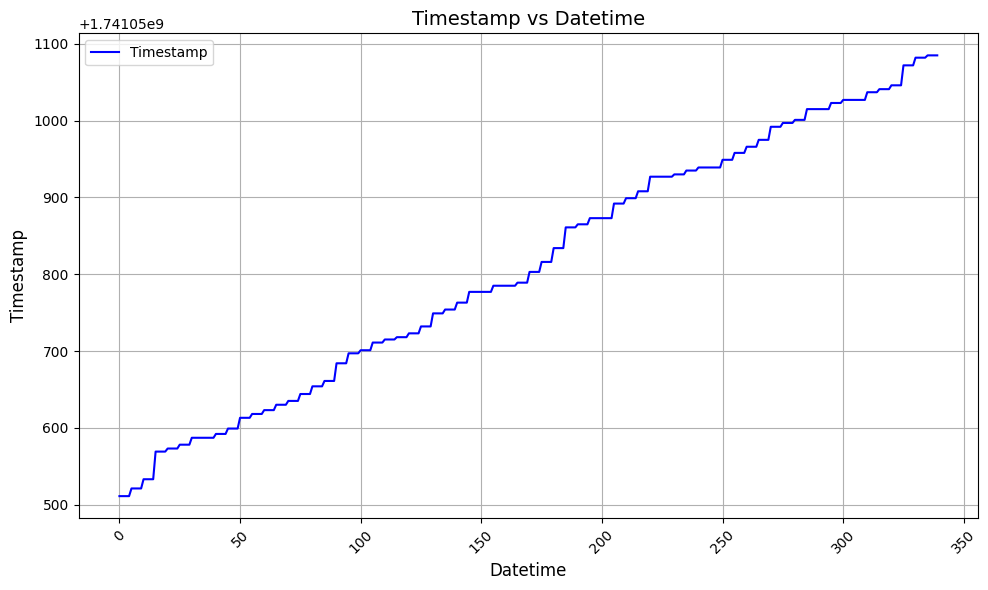

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta

# 예시로 datetime을 x축으로, timestamp를 y축으로 설정
plt.figure(figsize=(10, 6))

# 그래프 그리기
plt.plot(merged_df['Timestamp'], label='Timestamp', color='blue')

# 그래프 제목, 축 레이블 설정
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('tps', fontsize=12)

# x축 레이블 회전
plt.xticks(rotation=45)

# 그리드 추가
plt.grid(True)

# 레전드 추가
plt.legend()

# 그래프 보여주기
plt.tight_layout()
plt.show()


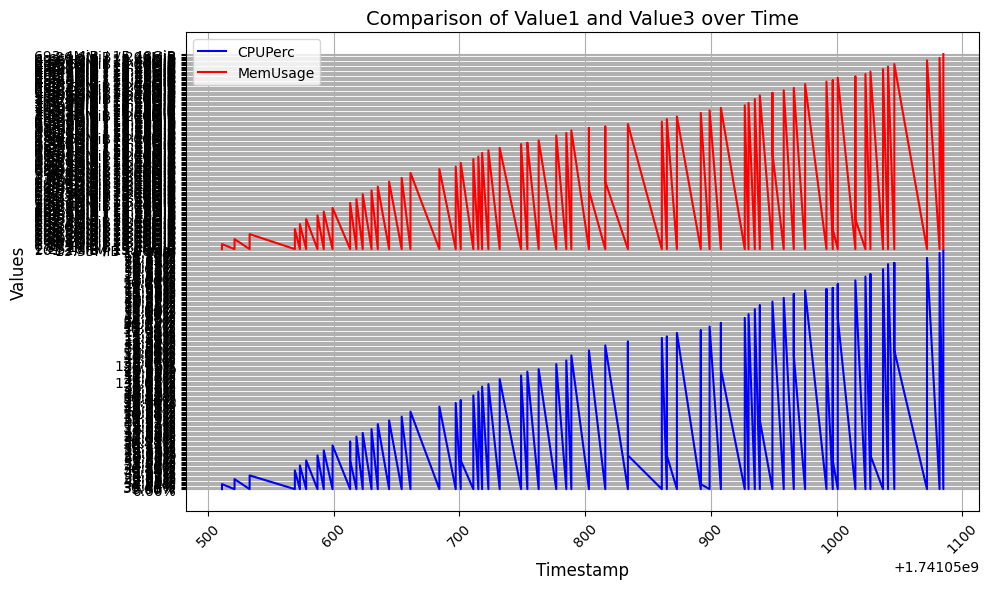

In [13]:
plt.figure(figsize=(10, 6))

# 그래프 그리기 (timestamp 기준으로 value1과 value3 비교)
plt.plot(merged_df['Timestamp'], merged_df['CPUPerc'], label='CPUPerc', color='blue')
plt.plot(merged_df['Timestamp'], merged_df['MemUsage'], label='MemUsage', color='red')

# 그래프 제목, 축 레이블 설정
plt.title('Comparison of Value1 and Value3 over Time', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Values', fontsize=12)

# x축 레이블 회전
plt.xticks(rotation=45)

# 그리드 추가
plt.grid(True)

# 레전드 추가
plt.legend()

# 그래프 보여주기
plt.tight_layout()
plt.show()